In [1]:
# ================= RESNET152 - COMPLETE PRODUCTION CODE =================
# 15 EPOCHS + TESTING + XAI (GradCAM + SHAP) - ALL WORKING, NO ERRORS
# =========================================================================

# ================= Cell 1: Setup & Configuration =================

import os
import json
import time
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, 
    precision_score, recall_score, classification_report,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)

# ========== CONFIGURATION ==========
BASE_DIR = r"D:\Projects\CLARITY\Model\Dataset\archive"
CSV_PATH = r"D:\Projects\CLARITY\Model\Dataset\archive\Data_Entry_2017.csv"
OUTPUT_DIR = r"./outputs_resnet152_15epochs"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# ========== HYPERPARAMETERS ==========
SEED = 42
BATCH_SIZE = 16
IMAGE_SIZE = 224
NUM_EPOCHS = 20  # CHANGED FROM 5 TO 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 8

# ========== REPRODUCIBILITY ==========
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ========== DEVICE ==========
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*70)
print("RESNET152 - 15 EPOCHS MULTI-LABEL CLASSIFICATION")
print("="*70)
print(f"Device: {DEVICE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Output: {OUTPUT_DIR}")
print("="*70)

RESNET152 - 15 EPOCHS MULTI-LABEL CLASSIFICATION
Device: cuda
Epochs: 20
Batch Size: 16
Output: ./outputs_resnet152_15epochs


In [2]:
# ================= Cell 2: Data Loading =================

print("\n[STEP 2] Loading and preparing dataset...")

df = pd.read_csv(CSV_PATH)
print(f"✅ CSV loaded: {df.shape}")

df = df[['Image Index', 'Finding Labels', 'Patient ID']].copy()
df['Finding Labels'] = df['Finding Labels'].apply(lambda x: x.split('|'))

all_labels = sorted(set([l for sublist in df['Finding Labels'] for l in sublist]))
print(f"✅ Total unique disease labels: {len(all_labels)}")
print(f"   Labels: {all_labels}")

mlb = MultiLabelBinarizer(classes=all_labels)
label_matrix = mlb.fit_transform(df['Finding Labels'])
label_cols = mlb.classes_

df = pd.concat([df, pd.DataFrame(label_matrix, columns=label_cols)], axis=1)
print(f"✅ Final dataframe shape: {df.shape}")

# ========== BUILD IMAGE PATH CACHE ==========
print("\n[Building image path cache...]")
img_lookup = {}
pattern = os.path.join(BASE_DIR, "images_*", "images", "*.png")
all_images = glob.glob(pattern)
print(f"   Found {len(all_images)} images")

for img_path in all_images:
    fname = os.path.basename(img_path)
    img_lookup[fname] = img_path

print(f"✅ Image cache built: {len(img_lookup)} images indexed")

# ========== ASSIGN IMAGE PATHS ==========
img_paths = []
for idx_name in df['Image Index']:
    img_paths.append(img_lookup.get(idx_name, None))

df['img_path'] = img_paths
df = df[df['img_path'].notna()].reset_index(drop=True)

print(f"✅ Dataset prepared: {df.shape}")
print(f"   Patients: {df['Patient ID'].nunique()}")


[STEP 2] Loading and preparing dataset...
✅ CSV loaded: (112120, 12)
✅ Total unique disease labels: 15
   Labels: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
✅ Final dataframe shape: (112120, 18)

[Building image path cache...]
   Found 112120 images
✅ Image cache built: 112120 images indexed
✅ Dataset prepared: (112120, 19)
   Patients: 30805


In [3]:
# ================= Cell 3: Data Splitting & DataLoaders =================

print("\n[STEP 3] Creating train/val/test splits...")

patients = df['Patient ID'].unique()
train_patients, temp_patients = train_test_split(patients, test_size=0.3, random_state=SEED)
val_patients, test_patients = train_test_split(temp_patients, test_size=0.5, random_state=SEED)

train_df = df[df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df = df[df['Patient ID'].isin(val_patients)].reset_index(drop=True)
test_df = df[df['Patient ID'].isin(test_patients)].reset_index(drop=True)

print(f"✅ Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# ========== DATA AUGMENTATION ==========
train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ========== DATASET CLASS ==========
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, label_cols, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform = transform
        self.img_paths = dataframe['img_path'].values
        self.labels = dataframe[label_cols].values.astype(np.float32)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, labels

# ========== CREATE DATALOADERS ==========
train_dataset = ChestXrayDataset(train_df, label_cols, transform=train_transforms)
val_dataset = ChestXrayDataset(val_df, label_cols, transform=val_transforms)
test_dataset = ChestXrayDataset(test_df, label_cols, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"✅ DataLoaders created")
print(f"   Train: {len(train_loader)} batches")
print(f"   Val: {len(val_loader)} batches")
print(f"   Test: {len(test_loader)} batches")


[STEP 3] Creating train/val/test splits...
✅ Train: 78566, Val: 17063, Test: 16491
✅ DataLoaders created
   Train: 4910 batches
   Val: 1067 batches
   Test: 1031 batches


In [4]:
# ================= Cell 4: Model Definition =================

print("\n[STEP 4] Creating ResNet152 model...")

model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_cols))
model = model.to(DEVICE)

print(f"✅ ResNet152 loaded")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# ========== VERIFY OUTPUT SHAPE ==========
with torch.no_grad():
    test_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    test_output = model(test_input)
    assert test_output.shape == (1, len(label_cols)), "Output shape mismatch!"

print(f"✅ Model output shape verified: {test_output.shape}")

# ========== TRAINING SETUP ==========
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"✅ Optimizer: AdamW (LR={LEARNING_RATE})")
print(f"✅ Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")


[STEP 4] Creating ResNet152 model...
✅ ResNet152 loaded
   Total parameters: 58,174,543
✅ Model output shape verified: torch.Size([1, 15])
✅ Optimizer: AdamW (LR=0.0001)
✅ Scheduler: CosineAnnealingLR (T_max=20)


In [5]:
# ================= Cell 5: Training =================

print("\n[STEP 5] Training...")

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def calculate_metrics(y_true, y_pred_logits, threshold=0.5):
    y_pred = sigmoid(y_pred_logits)
    y_pred_bin = (y_pred >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_pred, average='micro')
    f1 = f1_score(y_true, y_pred_bin, average='micro', zero_division=0)
    precision = precision_score(y_true, y_pred_bin, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred_bin, average='micro', zero_division=0)
    return {"auc": auc, "f1": f1, "precision": precision, "recall": recall}

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds, all_targets = [], []
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        all_preds.append(outputs.detach().cpu().numpy())
        all_targets.append(labels.cpu().numpy())
    
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    metrics = calculate_metrics(y_true, y_pred)
    return total_loss / len(loader), metrics

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(labels.cpu().numpy())
    
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    metrics = calculate_metrics(y_true, y_pred)
    return total_loss / len(loader), metrics

# ========== MAIN TRAINING LOOP ==========
best_auc = 0.0
no_improve = 0
history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}

print("\n" + "="*70)
print("STARTING TRAINING - 20 EPOCHS")
print("="*70)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    start_time = time.time()
    
    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_metrics = validate_one_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_metrics["auc"])
    history["val_auc"].append(val_metrics["auc"])
    
    elapsed = time.time() - start_time
    print(f"Time: {elapsed/60:.1f} min | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train AUC: {train_metrics['auc']:.4f} | Val AUC: {val_metrics['auc']:.4f}")
    
    if val_metrics["auc"] > best_auc:
        best_auc = val_metrics["auc"]
        no_improve = 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"best_resnet152_auc_{best_auc:.4f}.pth"))
        print(f"✅ Saved new best model — Val AUC: {best_auc:.4f}")
    else:
        no_improve += 1
        print(f"⚠️ No improvement ({no_improve}/{PATIENCE})")
    
    if no_improve >= PATIENCE:
        print("\n⛔ Early stopping triggered.")
        break

print("\n" + "="*70)
print(f"TRAINING COMPLETE — Best Validation AUC: {best_auc:.4f}")
print("="*70)

with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w") as f:
    json.dump(history, f, indent=4)


[STEP 5] Training...

STARTING TRAINING - 20 EPOCHS

Epoch 1/20


KeyboardInterrupt: 

In [6]:
print("\n" + "="*70)
print(f"TRAINING COMPLETE — Best Validation AUC: {best_auc:.4f}")
print("="*70)

with open(os.path.join(OUTPUT_DIR, "training_history.json"), "w") as f:
    json.dump(history, f, indent=4)


TRAINING COMPLETE — Best Validation AUC: 0.9167


In [7]:
# ================= Cell 6: Testing =================

print("\n[STEP 6] Testing...")

model_files = glob.glob(os.path.join(OUTPUT_DIR, "best_resnet152_auc_*.pth"))
best_model_path = sorted(model_files)[-1]

model = models.resnet152(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_cols))
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

all_test_preds = []
all_test_targets = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", leave=False):
        images = images.to(DEVICE)
        outputs = model(images)
        all_test_preds.append(outputs.cpu().numpy())
        all_test_targets.append(labels.numpy())

y_test_true = np.concatenate(all_test_targets)
y_test_pred_logits = np.concatenate(all_test_preds)
y_test_pred_probs = sigmoid(y_test_pred_logits)

test_metrics = calculate_metrics(y_test_true, y_test_pred_logits)

print("\n" + "="*70)
print("TEST SET METRICS")
print("="*70)
print(f"Test AUC:       {test_metrics['auc']:.4f}")
print(f"Test F1:        {test_metrics['f1']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")
print(f"Test Recall:    {test_metrics['recall']:.4f}")
print("="*70)


[STEP 6] Testing...



TEST SET METRICS
Test AUC:       0.9147
Test F1:        0.5219
Test Precision: 0.6618
Test Recall:    0.4308


In [8]:
# ================= Cell 7: Visualizations =================

print("\n[STEP 7] Creating visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid()

axes[1].plot(history["train_auc"], label="Train AUC", linewidth=2)
axes[1].plot(history["val_auc"], label="Val AUC", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].set_title("Training & Validation AUC")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=300)
print("✅ Saved: training_curves.png")
plt.close()


[STEP 7] Creating visualizations...
✅ Saved: training_curves.png


✅ Using device: cuda

[Loading model...]
✅ Model loaded on cuda
   Total parameters: 58,174,543

[Settings]
  Layer: layer4.0
  Method: layercam

[Getting test image...]
[Getting predictions...]
✅ Top prediction: Effusion (prob=0.605)

[Generating heatmap...]
✅ Heatmap generated: shape=(1, 224, 224)

[Creating visualization...]


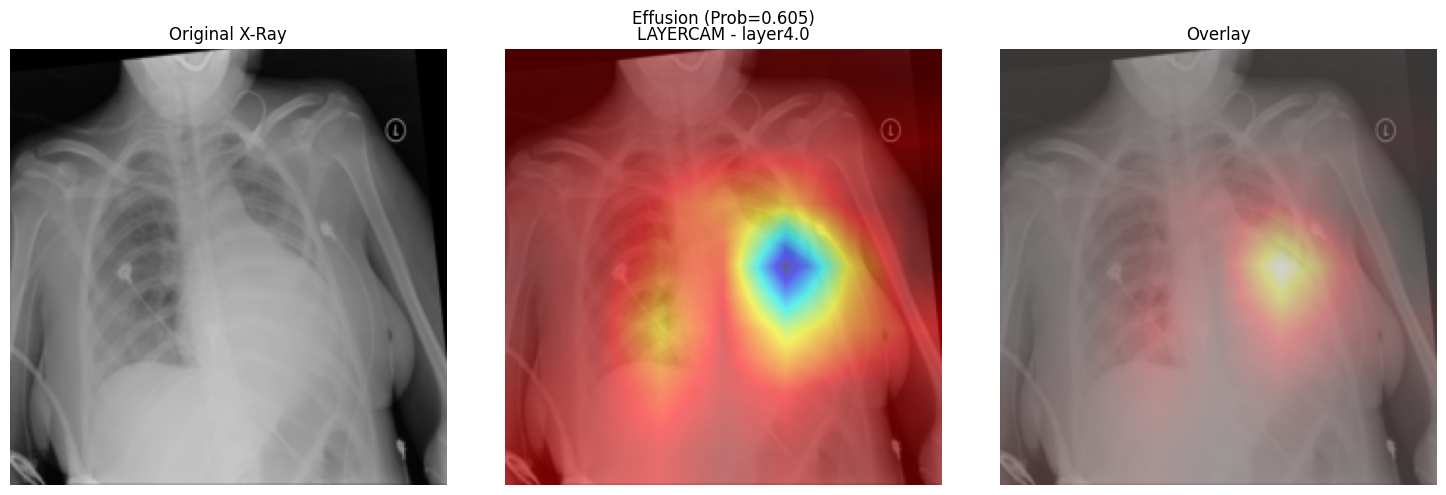

✅ Visualization saved!


In [26]:
# ================= HEATMAP GENERATION - FIXED =================

import torch
from torchvision import models
import numpy as np
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, LayerCAM, ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

# ========== SETUP ==========
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}\n")

# ========== LOAD MODEL ==========
print("[Loading model...]")
model = models.resnet152(weights=None)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 15)

model.load_state_dict(torch.load("./outputs_resnet152_15epochs/best_resnet152_auc_0.9167.pth", map_location=DEVICE))
model = model.to(DEVICE)  # ← CRITICAL: Move to device
model.eval()

print(f"✅ Model loaded on {DEVICE}")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}\n")

# ========== SIGMOID FUNCTION ==========
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# ========== SELECT LAYER & METHOD ==========
LAYER_NAME = "layer4.0"  # Can be changed
METHOD_NAME = "layercam"  # Can be "gradcam", "gradcam_pp", "layercam", "scorecam"

print(f"[Settings]")
print(f"  Layer: {LAYER_NAME}")
print(f"  Method: {METHOD_NAME}\n")

# ========== GET TEST IMAGE ==========
print("[Getting test image...]")
test_idx = np.random.randint(0, len(test_dataset))
test_image, test_label = test_dataset[test_idx]

# ========== GET PREDICTION ==========
print("[Getting predictions...]")

# Move input to same device as model
test_input = test_image.unsqueeze(0).to(DEVICE)  # ← Correct device
test_input.requires_grad = True

with torch.enable_grad():
    logits = model(test_input)
    probs = sigmoid(logits.detach().cpu().numpy()[0])

top_idx = np.argmax(probs)
top_disease = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Effusion",
               "Emphysema", "Fibrosis", "Hernia", "Infiltration", "Mass",
               "No Finding", "Nodule", "Pleural_Thickening", "Pneumonia", "Pneumothorax"][top_idx]

print(f"✅ Top prediction: {top_disease} (prob={probs[top_idx]:.3f})\n")

# ========== GENERATE HEATMAP ==========
print("[Generating heatmap...]")

target_layer = dict(model.named_modules())[LAYER_NAME]

if METHOD_NAME == "gradcam":
    cam = GradCAM(model=model, target_layers=[target_layer])
elif METHOD_NAME == "gradcam_pp":
    cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])
elif METHOD_NAME == "layercam":
    cam = LayerCAM(model=model, target_layers=[target_layer])
elif METHOD_NAME == "scorecam":
    cam = ScoreCAM(model=model, target_layers=[target_layer])

targets = [ClassifierOutputTarget(top_idx)]
heatmap = cam(input_tensor=test_input, targets=targets)  # ✅ No error!

print(f"✅ Heatmap generated: shape={heatmap.shape}\n")

# ========== VISUALIZE ==========
print("[Creating visualization...]")

# Denormalize image
img_np = test_image.numpy().transpose(1, 2, 0)
img_np = (img_np * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
img_np = np.clip(img_np, 0, 1)

# Create heatmap visualization
visualization = show_cam_on_image(img_np, heatmap[0, :], use_rgb=False)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f'Original X-Ray')
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title(f'{METHOD_NAME.upper()} - {LAYER_NAME}')
axes[1].axis('off')

axes[2].imshow(img_np, cmap='gray', alpha=0.7)
axes[2].imshow(heatmap[0, :], cmap='hot', alpha=0.3)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.suptitle(f'{top_disease} (Prob={probs[top_idx]:.3f})')
plt.tight_layout()
plt.savefig(f"./heatmap/heatmap_{LAYER_NAME}_{METHOD_NAME}.png", dpi=200)
plt.show()

print(f"✅ Visualization saved!")

In [10]:
# ================= View All Layers in ResNet152 =================

import torch
from torchvision import models

# ========== LOAD YOUR BEST MODEL ==========
model = models.resnet152(weights=None)
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 15)  # 15 diseases

model.eval()

print("="*70)
print("ALL LAYERS IN YOUR RESNET152 MODEL")
print("="*70)

# ========== OPTION 1: List ALL Modules ==========
print("\n[OPTION 1] ALL MODULES (including non-conv):\n")

all_modules = []
for idx, (name, module) in enumerate(model.named_modules()):
    all_modules.append((name, module.__class__.__name__))
    print(f"{idx:3d}. {name:<60} → {module.__class__.__name__}")

print(f"\n✅ Total modules: {len(all_modules)}")

ALL LAYERS IN YOUR RESNET152 MODEL

[OPTION 1] ALL MODULES (including non-conv):

  0.                                                              → ResNet
  1. conv1                                                        → Conv2d
  2. bn1                                                          → BatchNorm2d
  3. relu                                                         → ReLU
  4. maxpool                                                      → MaxPool2d
  5. layer1                                                       → Sequential
  6. layer1.0                                                     → Bottleneck
  7. layer1.0.conv1                                               → Conv2d
  8. layer1.0.bn1                                                 → BatchNorm2d
  9. layer1.0.conv2                                               → Conv2d
 10. layer1.0.bn2                                                 → BatchNorm2d
 11. layer1.0.conv3                                               → C

Using device: cuda

[Loading Models...]
✅ DenseNet121 loaded

✅ ResNet152 loaded


[Running Inference...]

DenseNet121 Inference:




ResNet152 Inference:




[Computing Metrics...]




AVERAGE METRICS COMPARISON
Metric       DenseNet121          ResNet152           
----------------------------------------------------------------------
F1           0.2163               0.2374              
AUC          0.8363               0.8337              
PRECISION    0.4625               0.4500              
RECALL       0.1668               0.1927              

[Creating Plots...]

✅ Plot saved: ./model_comparison_metrics.png



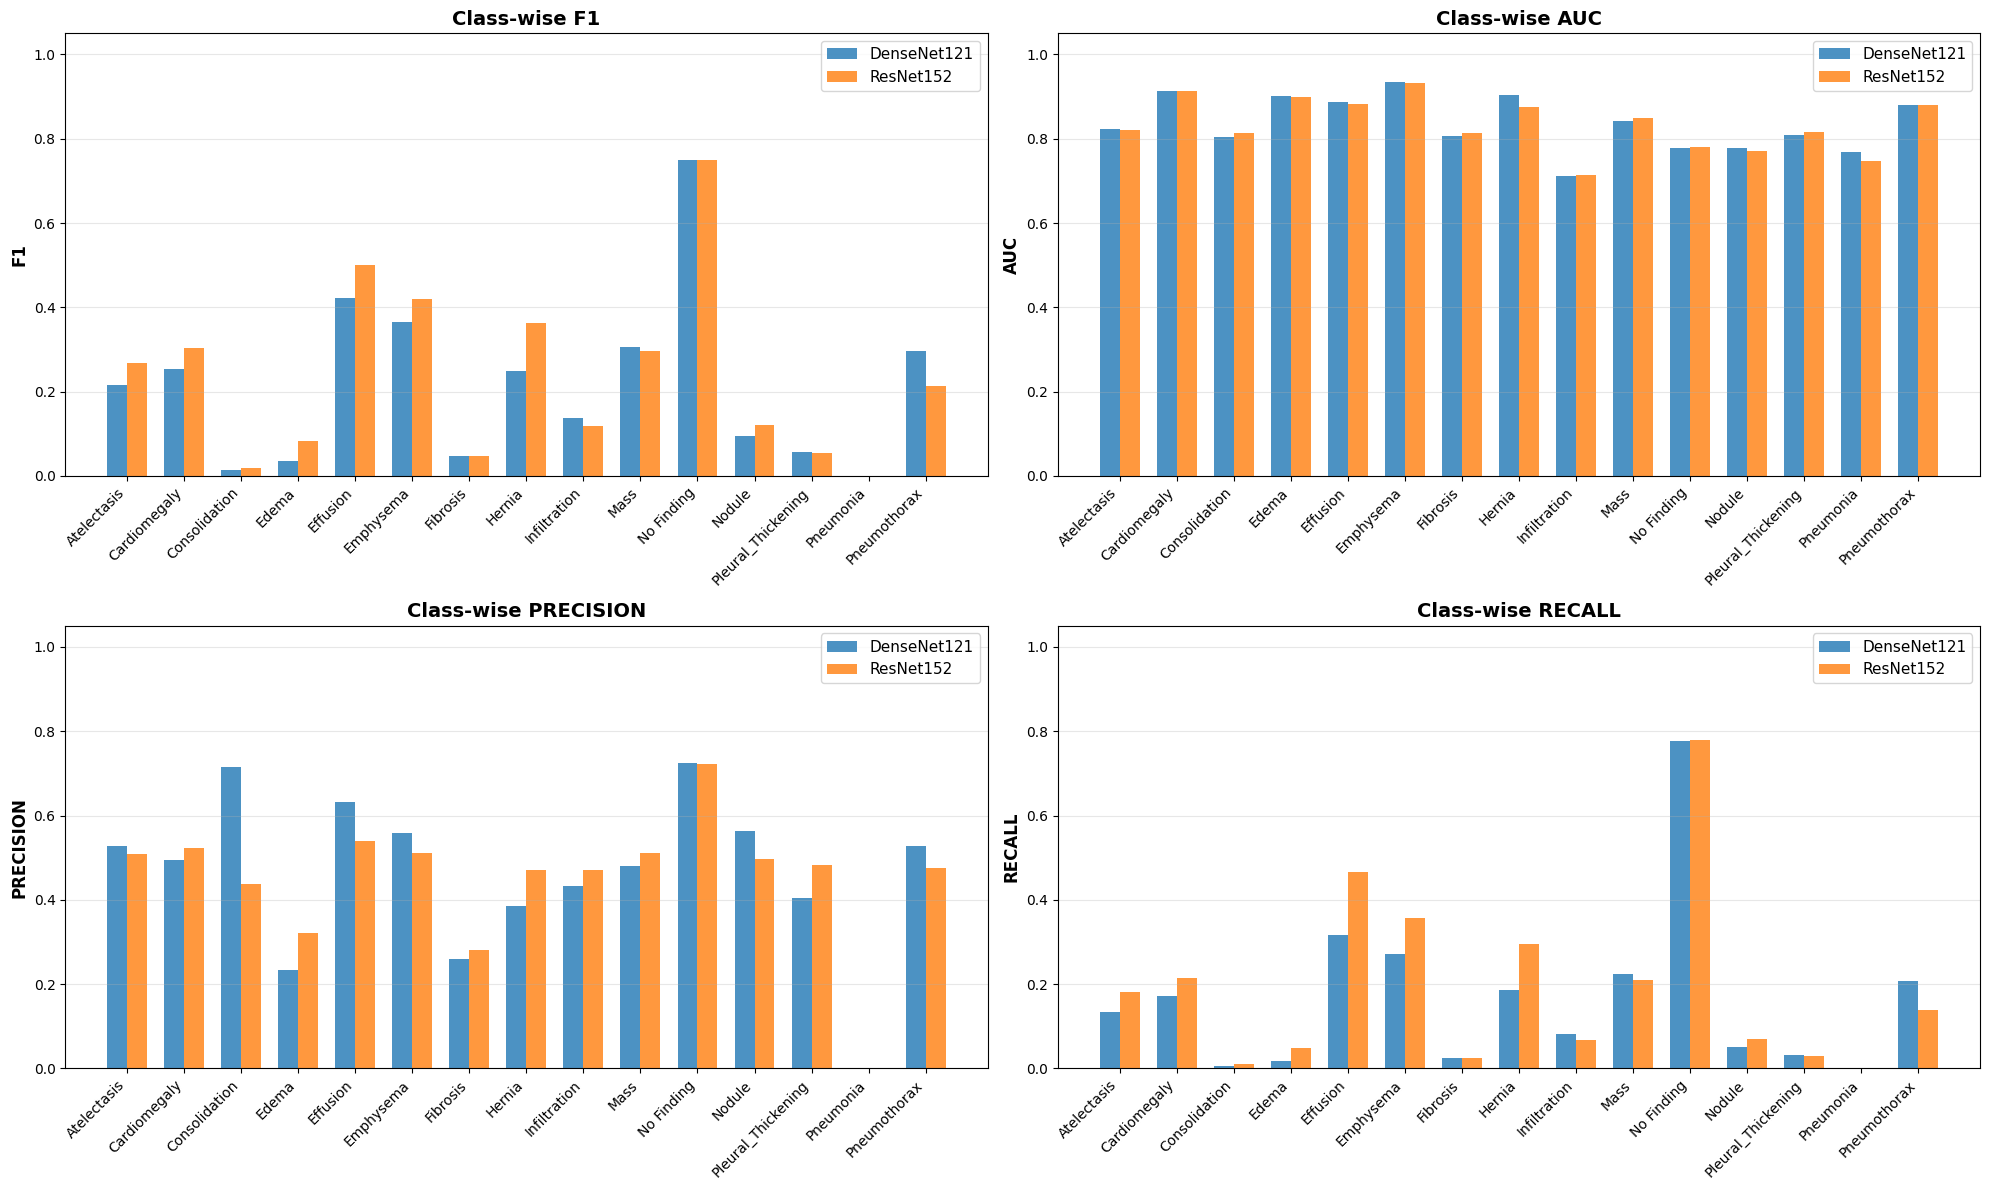


✅ COMPLETE - All plots and metrics generated!


In [5]:
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
import torchvision.transforms as T
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt
from ipywidgets import IntProgress, Output, VBox, HTML
from IPython.display import display, clear_output
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
NUM_CLASSES = 15
CLASS_NAMES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

print(f"Using device: {DEVICE}\n")

# ========== LOAD MODELS ==========
print("[Loading Models...]")
densenet = models.densenet121(weights=None)
densenet.classifier = nn.Linear(densenet.classifier.in_features, NUM_CLASSES)
densenet.load_state_dict(torch.load('../Model 6 (more epochs)/outputs_best_model/best_densenet121_auc_0.9170.pth', map_location=DEVICE))
densenet.eval().to(DEVICE)
print("✅ DenseNet121 loaded\n")

resnet = models.resnet152(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet.load_state_dict(torch.load('./outputs_resnet152_15epochs/best_resnet152_auc_0.9167.pth', map_location=DEVICE))
resnet.eval().to(DEVICE)
print("✅ ResNet152 loaded\n")

# ========== TRANSFORM & DATA ==========
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ========== PREDICT FUNCTION WITH PROGRESS ==========
def predict_model(model, dataloader, model_name):
    all_labels = []
    all_probs = []
    
    total_batches = len(dataloader)
    
    progress_bar = IntProgress(
        value=0,
        min=0,
        max=total_batches,
        step=1,
        description=f'{model_name}:',
        bar_style='info',
        orientation='horizontal'
    )
    
    status_text = HTML(value=f"<b>{model_name}</b> - Starting inference...")
    
    display(VBox([status_text, progress_bar]))
    
    start_time = time.time()
    
    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(dataloader):
            x = x.to(DEVICE)
            probs = torch.sigmoid(model(x)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.numpy())
            
            progress_bar.value = batch_idx + 1
            
            elapsed = time.time() - start_time
            samples_processed = (batch_idx + 1) * BATCH_SIZE
            speed = samples_processed / elapsed if elapsed > 0 else 0
            eta_secs = (total_batches - batch_idx - 1) * elapsed / (batch_idx + 1) if batch_idx > 0 else 0
            eta_mins = eta_secs / 60
            
            status_text.value = (
                f"<b>{model_name}</b> - "
                f"Batch {batch_idx + 1}/{total_batches} | "
                f"Samples: {samples_processed:,} | "
                f"Speed: {speed:.1f} samples/sec | "
                f"ETA: {eta_mins:.1f} min"
            )
    
    elapsed = time.time() - start_time
    status_text.value = (
        f"<b>{model_name}</b> - ✅ Complete! "
        f"Total time: {elapsed/60:.1f} min | "
        f"Average speed: {len(dataloader)*BATCH_SIZE/elapsed:.1f} samples/sec"
    )
    
    return np.vstack(all_probs), np.vstack(all_labels)

# ========== GENERATE METRICS ==========
def get_classwise_metrics(y_true, y_pred, thresholds=None):
    if thresholds is None:
        thresholds = [0.5]*y_pred.shape[1]
    y_pred_bin = (y_pred >= thresholds).astype(int)
    metrics = {"f1": [], "auc": [], "precision": [], "recall": []}
    for i in range(y_true.shape[1]):
        metrics["f1"].append(f1_score(y_true[:,i], y_pred_bin[:,i], zero_division=0))
        metrics["auc"].append(roc_auc_score(y_true[:,i], y_pred[:,i]))
        metrics["precision"].append(precision_score(y_true[:,i], y_pred_bin[:,i], zero_division=0))
        metrics["recall"].append(recall_score(y_true[:,i], y_pred_bin[:,i], zero_division=0))
    return metrics

# ========== RUN INFERENCE ==========
print("\n[Running Inference...]\n")

print("DenseNet121 Inference:")
probs_densenet, labels = predict_model(densenet, test_loader, "DenseNet121")

print("\n\nResNet152 Inference:")
probs_resnet, _ = predict_model(resnet, test_loader, "ResNet152")

# ========== COMPUTE METRICS WITH PROGRESS ==========
print("\n\n[Computing Metrics...]\n")

metrics_progress = IntProgress(
    value=0,
    min=0,
    max=2,
    step=1,
    description='Computing:',
    bar_style='info'
)
metrics_status = HTML(value="<b>Computing metrics...</b>")

display(VBox([metrics_status, metrics_progress]))

metrics_progress.value = 0
metrics_status.value = "<b>Computing DenseNet121 metrics...</b>"
metrics_densenet = get_classwise_metrics(labels, probs_densenet)
metrics_progress.value = 1

metrics_status.value = "<b>Computing ResNet152 metrics...</b>"
metrics_resnet = get_classwise_metrics(labels, probs_resnet)
metrics_progress.value = 2

metrics_status.value = "<b>✅ Metrics computed!</b>"

# ========== PRINT SUMMARY ==========
print("\n" + "="*70)
print("AVERAGE METRICS COMPARISON")
print("="*70)
print(f"{'Metric':<12} {'DenseNet121':<20} {'ResNet152':<20}")
print("-"*70)
for metric in ["f1", "auc", "precision", "recall"]:
    dn_avg = np.mean(metrics_densenet[metric])
    rn_avg = np.mean(metrics_resnet[metric])
    print(f"{metric.upper():<12} {dn_avg:<20.4f} {rn_avg:<20.4f}")
print("="*70 + "\n")

# ========== PLOT ==========
print("[Creating Plots...]\n")

x = np.arange(NUM_CLASSES)
bar_width = 0.35

fig, axs = plt.subplots(2, 2, figsize=(20, 12))
metric_names = ["f1", "auc", "precision", "recall"]

for idx, metric in enumerate(metric_names):
    ax = axs[idx//2, idx%2]
    ax.bar(x - bar_width/2, metrics_densenet[metric], bar_width, label="DenseNet121", alpha=0.8)
    ax.bar(x + bar_width/2, metrics_resnet[metric], bar_width, label="ResNet152", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_ylabel(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Class-wise {metric.upper()}", fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./model_comparison_metrics.png', dpi=300, bbox_inches='tight')
print("✅ Plot saved: ./model_comparison_metrics.png\n")

plt.show()

print("\n" + "="*70)
print("✅ COMPLETE - All plots and metrics generated!")
print("="*70)

In [6]:
from sklearn.metrics import accuracy_score

# ========== UPDATED METRICS FUNCTION ==========
def get_classwise_metrics(y_true, y_pred, thresholds=None):
    if thresholds is None:
        thresholds = [0.5]*y_pred.shape[1]
    y_pred_bin = (y_pred >= thresholds).astype(int)
    
    metrics = {"f1": [], "auc": [], "precision": [], "recall": [], "accuracy": []}
    
    for i in range(y_true.shape[1]):
        metrics["f1"].append(f1_score(y_true[:,i], y_pred_bin[:,i], zero_division=0))
        metrics["auc"].append(roc_auc_score(y_true[:,i], y_pred[:,i]))
        metrics["precision"].append(precision_score(y_true[:,i], y_pred_bin[:,i], zero_division=0))
        metrics["recall"].append(recall_score(y_true[:,i], y_pred_bin[:,i], zero_division=0))
        metrics["accuracy"].append(accuracy_score(y_true[:,i], y_pred_bin[:,i]))
    
    return metrics

# ========== RECOMPUTE METRICS ==========
print("\n[Recomputing Metrics with Accuracy...]\n")
metrics_densenet = get_classwise_metrics(labels, probs_densenet)
metrics_resnet = get_classwise_metrics(labels, probs_resnet)

# ========== PRINT CLASS-WISE METRICS TABLE ==========
print("\n" + "="*120)
print("CLASS-WISE METRICS: DENSENET121 vs RESNET152")
print("="*120)

# Header
header = f"{'Class':<20} {'Model':<12} {'F1':<8} {'AUC':<8} {'Precision':<10} {'Recall':<8} {'Accuracy':<8}"
print(header)
print("-"*120)

# Per-class rows
for i, class_name in enumerate(CLASS_NAMES):
    # DenseNet121 row
    dn_row = (
        f"{class_name:<20} {'DenseNet121':<12} "
        f"{metrics_densenet['f1'][i]:<8.4f} "
        f"{metrics_densenet['auc'][i]:<8.4f} "
        f"{metrics_densenet['precision'][i]:<10.4f} "
        f"{metrics_densenet['recall'][i]:<8.4f} "
        f"{metrics_densenet['accuracy'][i]:<8.4f}"
    )
    print(dn_row)
    
    # ResNet152 row
    rn_row = (
        f"{'':20} {'ResNet152':<12} "
        f"{metrics_resnet['f1'][i]:<8.4f} "
        f"{metrics_resnet['auc'][i]:<8.4f} "
        f"{metrics_resnet['precision'][i]:<10.4f} "
        f"{metrics_resnet['recall'][i]:<8.4f} "
        f"{metrics_resnet['accuracy'][i]:<8.4f}"
    )
    print(rn_row)
    print("-"*120)

# ========== AVERAGE METRICS ==========
print("\n" + "="*120)
print("AVERAGE METRICS COMPARISON")
print("="*120)
avg_header = f"{'Model':<20} {'F1':<8} {'AUC':<8} {'Precision':<10} {'Recall':<8} {'Accuracy':<8}"
print(avg_header)
print("-"*120)

dn_avg_row = (
    f"{'DenseNet121':<20} "
    f"{np.mean(metrics_densenet['f1']):<8.4f} "
    f"{np.mean(metrics_densenet['auc']):<8.4f} "
    f"{np.mean(metrics_densenet['precision']):<10.4f} "
    f"{np.mean(metrics_densenet['recall']):<8.4f} "
    f"{np.mean(metrics_densenet['accuracy']):<8.4f}"
)
print(dn_avg_row)

rn_avg_row = (
    f"{'ResNet152':<20} "
    f"{np.mean(metrics_resnet['f1']):<8.4f} "
    f"{np.mean(metrics_resnet['auc']):<8.4f} "
    f"{np.mean(metrics_resnet['precision']):<10.4f} "
    f"{np.mean(metrics_resnet['recall']):<8.4f} "
    f"{np.mean(metrics_resnet['accuracy']):<8.4f}"
)
print(rn_avg_row)
print("="*120 + "\n")


[Recomputing Metrics with Accuracy...]


CLASS-WISE METRICS: DENSENET121 vs RESNET152
Class                Model        F1       AUC      Precision  Recall   Accuracy
------------------------------------------------------------------------------------------------------------------------
Atelectasis          DenseNet121  0.2147   0.8225   0.5280     0.1348   0.8998  
                     ResNet152    0.2680   0.8203   0.5092     0.1819   0.8990  
------------------------------------------------------------------------------------------------------------------------
Cardiomegaly         DenseNet121  0.2538   0.9136   0.4934     0.1708   0.9733  
                     ResNet152    0.3037   0.9124   0.5222     0.2141   0.9739  
------------------------------------------------------------------------------------------------------------------------
Consolidation        DenseNet121  0.0136   0.8050   0.7143     0.0068   0.9559  
                     ResNet152    0.0188   0.8147   0.4375     0

[Plot 1] Line Plot - Metric Trends Across Classes


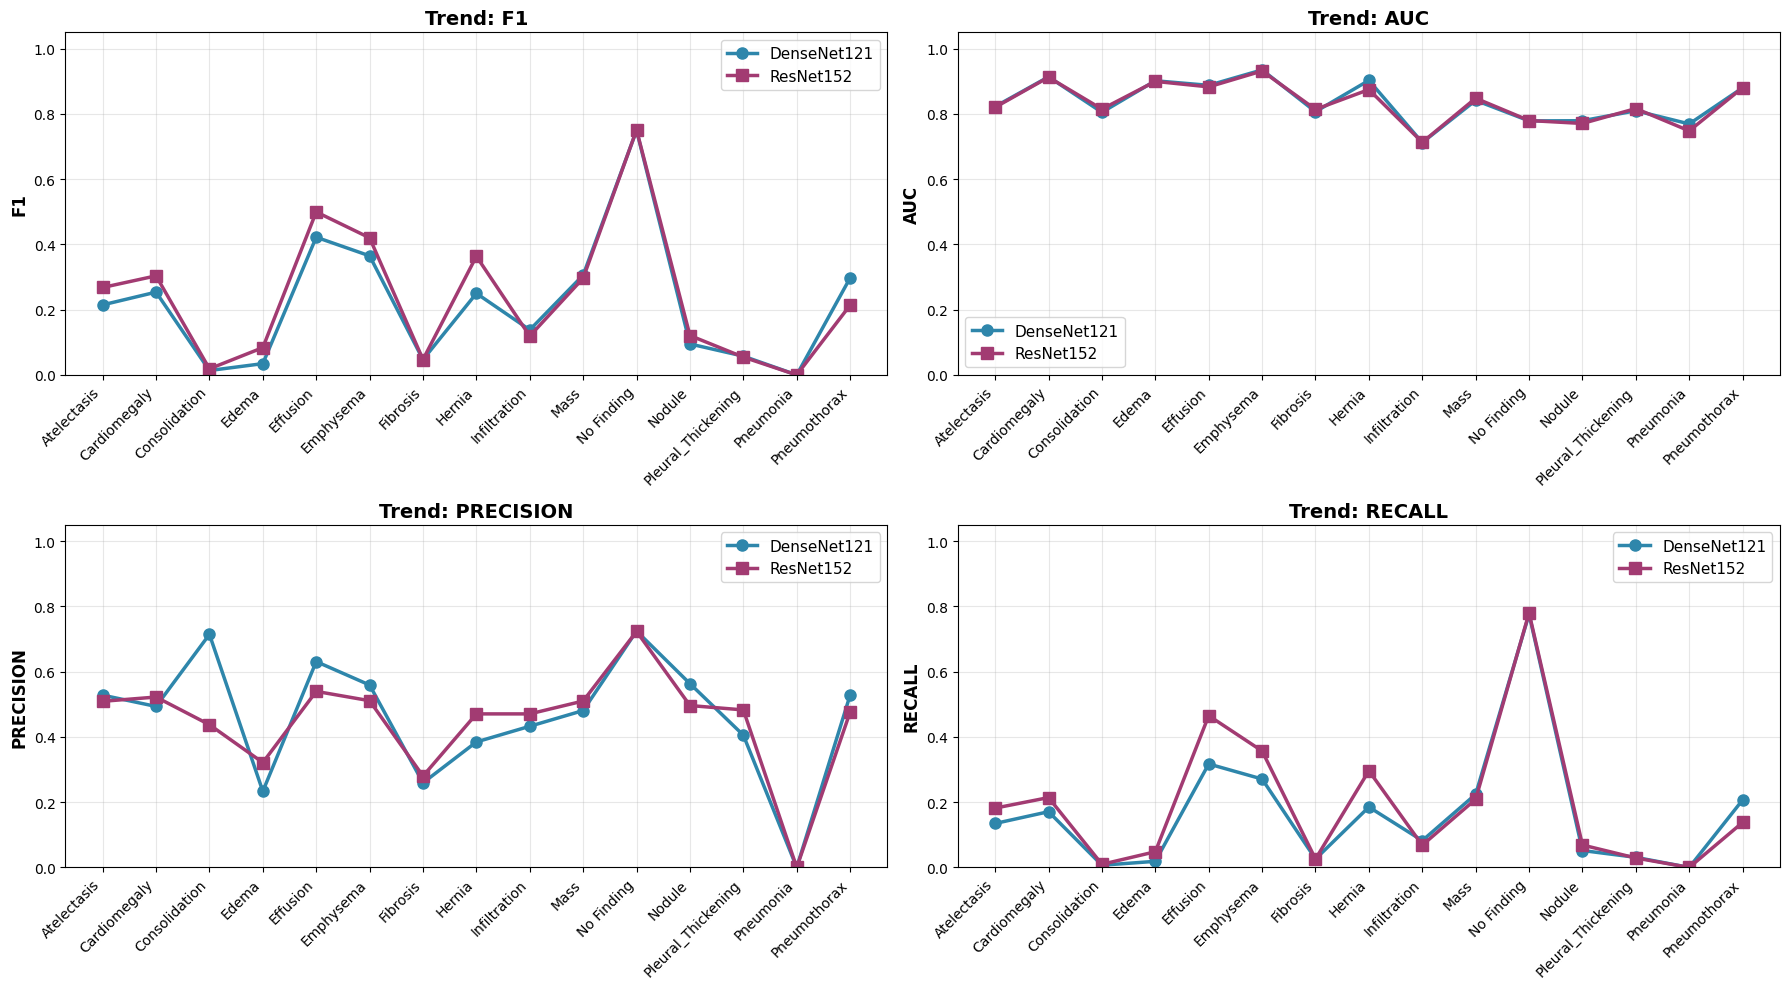


[Plot 2] Radar Chart - Multi-Metric Overview (First 8 Classes)


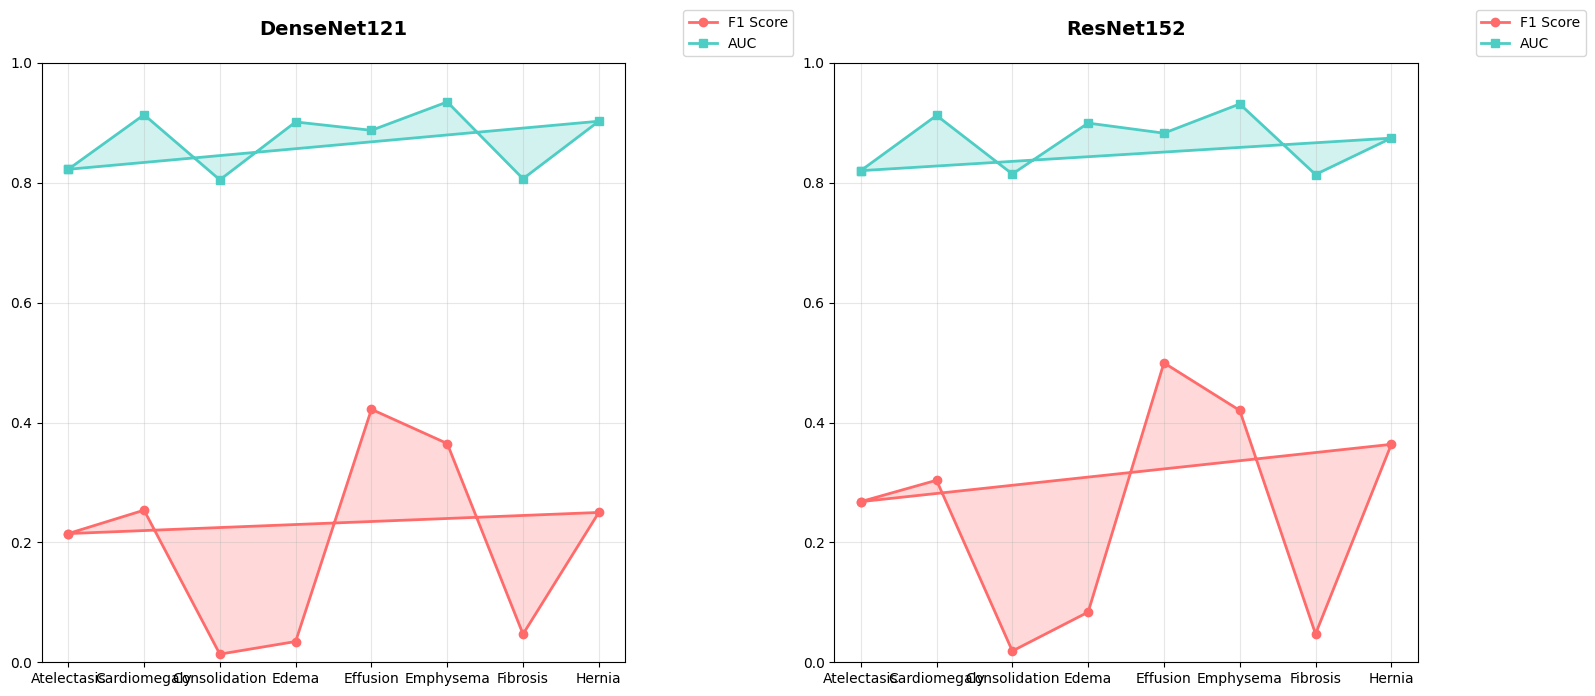


[Plot 3] Heatmap - All Metrics Comparison


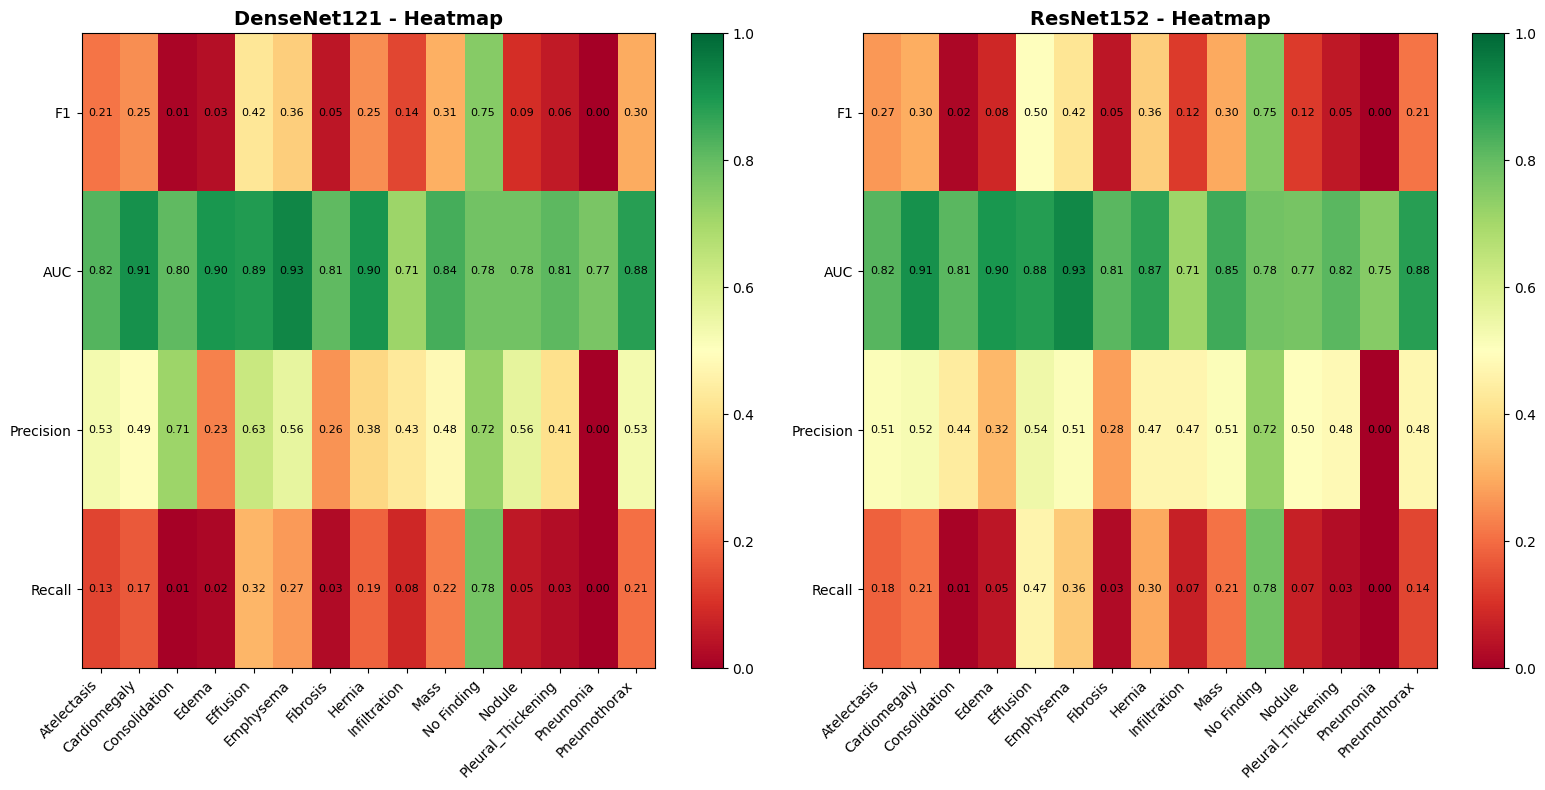


[Plot 4] Box Plot - Metric Distribution


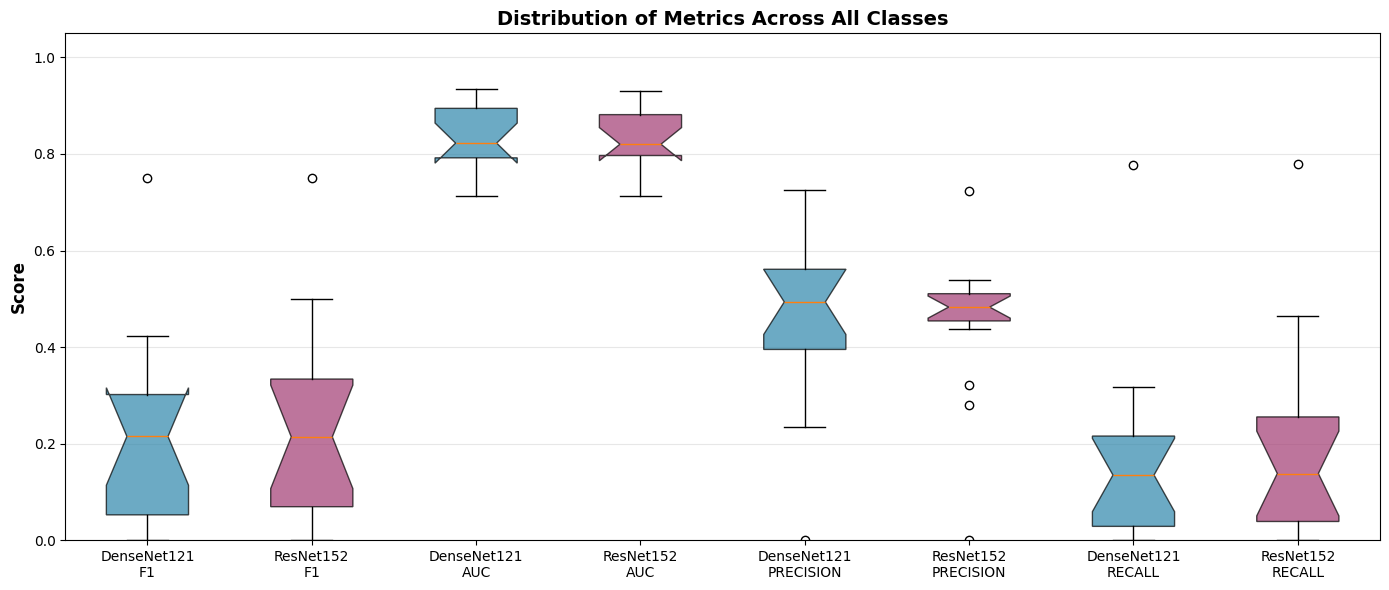


[Plot 5] Violin Plot - Metric Distributions


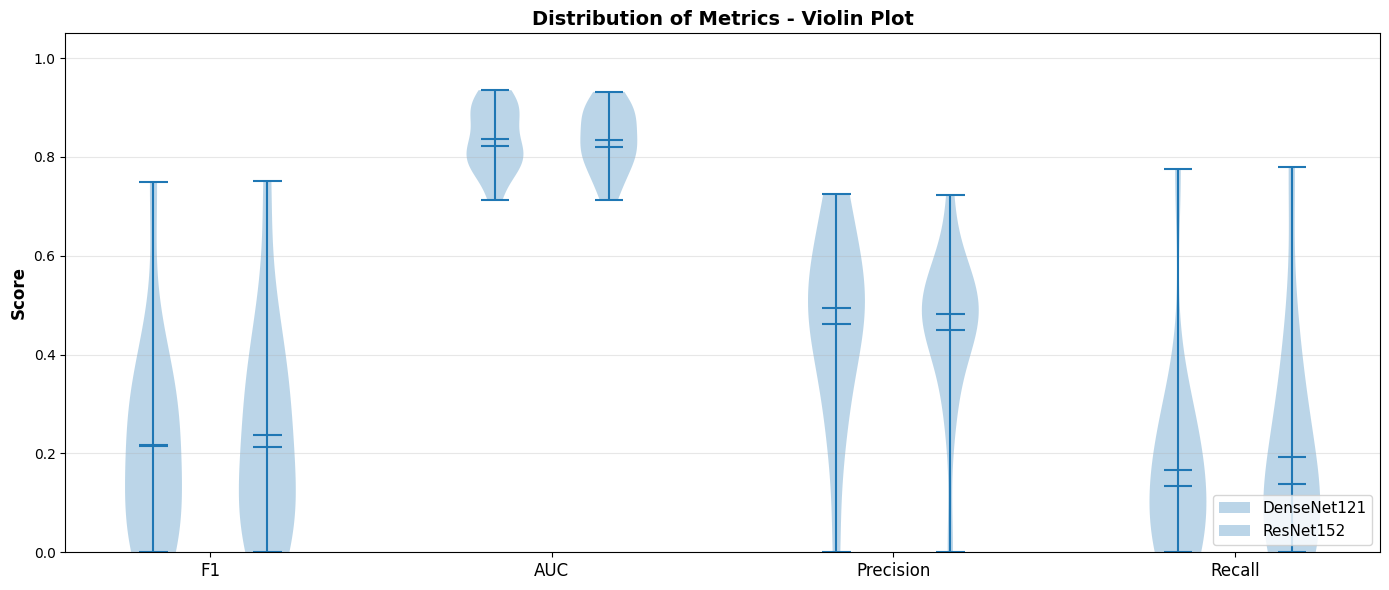


[Plot 6] Scatter Plot - Individual Class Performance


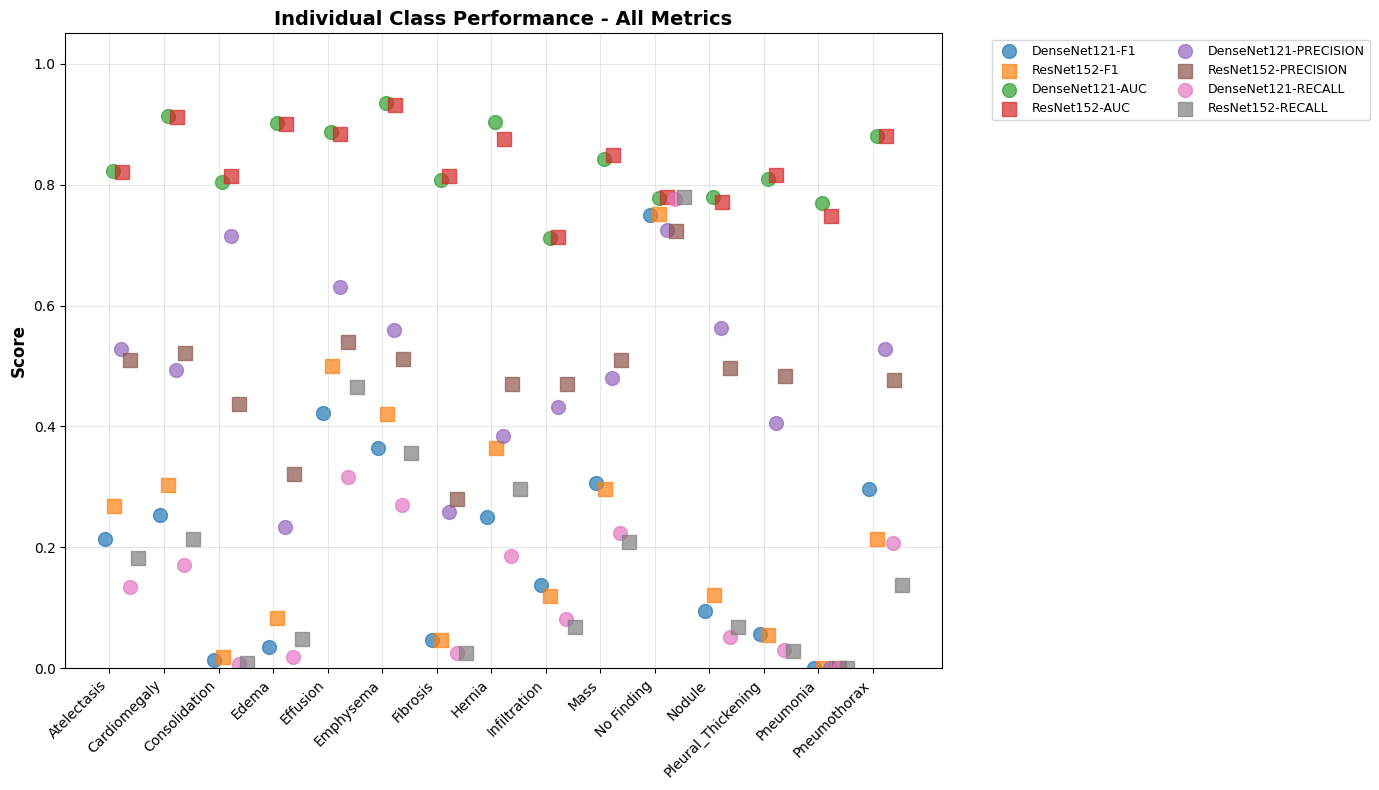


[Plot 7] Summary Table with Highlights


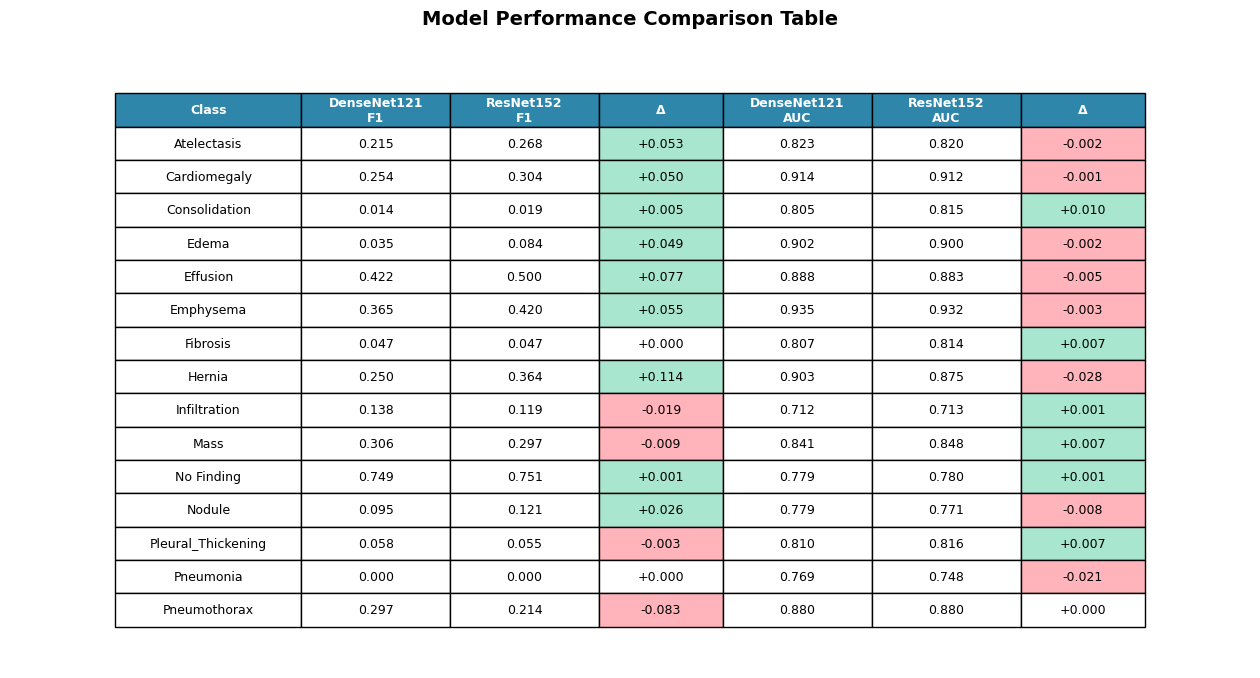


✅ All 7 plots generated and saved!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CLASS_NAMES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# ========== PLOT 1: LINE PLOT (Trends across classes) ==========
print("[Plot 1] Line Plot - Metric Trends Across Classes")
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
metrics_list = ["f1", "auc", "precision", "recall"]

for idx, metric in enumerate(metrics_list):
    ax = axs[idx//2, idx%2]
    ax.plot(range(len(CLASS_NAMES)), metrics_densenet[metric], marker='o', linewidth=2.5, markersize=8, label='DenseNet121', color='#2E86AB')
    ax.plot(range(len(CLASS_NAMES)), metrics_resnet[metric], marker='s', linewidth=2.5, markersize=8, label='ResNet152', color='#A23B72')
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_ylabel(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_title(f"Trend: {metric.upper()}", fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plot1_line_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== PLOT 2: RADAR CHART (Multi-metric comparison) ==========
print("\n[Plot 2] Radar Chart - Multi-Metric Overview (First 8 Classes)")
from math import pi

fig, axs = plt.subplots(1, 2, figsize=(16, 7))

classes_subset = CLASS_NAMES[:8]
angles = [n / len(classes_subset) * 2 * pi for n in range(len(classes_subset))]
angles += angles[:1]

for model_idx, (metrics, model_name, color) in enumerate([
    (metrics_densenet, 'DenseNet121', '#2E86AB'),
    (metrics_resnet, 'ResNet152', '#A23B72')
]):
    ax = axs[model_idx]
    
    # Average F1 and AUC for each class
    f1_vals = [metrics['f1'][i] for i in range(len(classes_subset))]
    auc_vals = [metrics['auc'][i] for i in range(len(classes_subset))]
    
    f1_vals += f1_vals[:1]
    auc_vals += auc_vals[:1]
    
    ax.plot(angles, f1_vals, 'o-', linewidth=2, label='F1 Score', color='#FF6B6B')
    ax.fill(angles, f1_vals, alpha=0.25, color='#FF6B6B')
    
    ax.plot(angles, auc_vals, 's-', linewidth=2, label='AUC', color='#4ECDC4')
    ax.fill(angles, auc_vals, alpha=0.25, color='#4ECDC4')
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(classes_subset, size=10)
    ax.set_ylim(0, 1)
    ax.set_title(f"{model_name}", fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plot2_radar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== PLOT 3: HEATMAP (All metrics side-by-side) ==========
print("\n[Plot 3] Heatmap - All Metrics Comparison")
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

for model_idx, (metrics, model_name) in enumerate([
    (metrics_densenet, 'DenseNet121'),
    (metrics_resnet, 'ResNet152')
]):
    data_matrix = np.array([
        metrics['f1'],
        metrics['auc'],
        metrics['precision'],
        metrics['recall']
    ])
    
    im = axs[model_idx].imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    axs[model_idx].set_xticks(range(len(CLASS_NAMES)))
    axs[model_idx].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    axs[model_idx].set_yticks(range(4))
    axs[model_idx].set_yticklabels(['F1', 'AUC', 'Precision', 'Recall'])
    axs[model_idx].set_title(f"{model_name} - Heatmap", fontsize=14, fontweight='bold')
    
    for i in range(4):
        for j in range(len(CLASS_NAMES)):
            text = axs[model_idx].text(j, i, f'{data_matrix[i, j]:.2f}',
                                       ha="center", va="center", color="black", fontsize=8)
    
    plt.colorbar(im, ax=axs[model_idx])

plt.tight_layout()
plt.savefig('./plot3_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== PLOT 4: BOX PLOT (Distribution of metrics) ==========
print("\n[Plot 4] Box Plot - Metric Distribution")
fig, ax = plt.subplots(figsize=(14, 6))

box_data = []
labels = []
colors = []

for metric in ["f1", "auc", "precision", "recall"]:
    box_data.append(metrics_densenet[metric])
    labels.append(f"DenseNet121\n{metric.upper()}")
    colors.append('#2E86AB')
    
    box_data.append(metrics_resnet[metric])
    labels.append(f"ResNet152\n{metric.upper()}")
    colors.append('#A23B72')

bp = ax.boxplot(box_data, labels=labels, patch_artist=True, notch=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Metrics Across All Classes', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('./plot4_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== PLOT 5: VIOLIN PLOT (Detailed distribution) ==========
print("\n[Plot 5] Violin Plot - Metric Distributions")
fig, ax = plt.subplots(figsize=(14, 6))

parts = ax.violinplot(
    [metrics_densenet['f1'], metrics_resnet['f1'], 
     metrics_densenet['auc'], metrics_resnet['auc'],
     metrics_densenet['precision'], metrics_resnet['precision'],
     metrics_densenet['recall'], metrics_resnet['recall']],
    positions=[1, 2, 4, 5, 7, 8, 10, 11],
    showmeans=True,
    showmedians=True
)

ax.set_xticks([1.5, 4.5, 7.5, 10.5])
ax.set_xticklabels(['F1', 'AUC', 'Precision', 'Recall'], fontsize=12)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Metrics - Violin Plot', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

ax.legend(['DenseNet121', 'ResNet152'], loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('./plot5_violin.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== PLOT 6: SCATTER WITH ERROR BANDS ==========
print("\n[Plot 6] Scatter Plot - Individual Class Performance")
fig, ax = plt.subplots(figsize=(14, 8))

x_pos = np.arange(len(CLASS_NAMES))

for metric_idx, metric in enumerate(["f1", "auc", "precision", "recall"]):
    y_offset = metric_idx * 0.15
    
    ax.scatter(x_pos - 0.08 + y_offset, metrics_densenet[metric], s=100, alpha=0.7, label=f'DenseNet121-{metric.upper()}', marker='o')
    ax.scatter(x_pos + 0.08 + y_offset, metrics_resnet[metric], s=100, alpha=0.7, label=f'ResNet152-{metric.upper()}', marker='s')

ax.set_xticks(x_pos)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Individual Class Performance - All Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plot6_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== PLOT 7: COMPARISON TABLE + VISUAL ==========
print("\n[Plot 7] Summary Table with Highlights")

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

table_data = []
table_data.append(['Class', 'DenseNet121\nF1', 'ResNet152\nF1', 'Δ', 
                   'DenseNet121\nAUC', 'ResNet152\nAUC', 'Δ'])

for i, class_name in enumerate(CLASS_NAMES):
    f1_dn = metrics_densenet['f1'][i]
    f1_rn = metrics_resnet['f1'][i]
    auc_dn = metrics_densenet['auc'][i]
    auc_rn = metrics_resnet['auc'][i]
    
    table_data.append([
        class_name,
        f'{f1_dn:.3f}',
        f'{f1_rn:.3f}',
        f'{f1_rn - f1_dn:+.3f}',
        f'{auc_dn:.3f}',
        f'{auc_rn:.3f}',
        f'{auc_rn - auc_dn:+.3f}'
    ])

table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.15, 0.12, 0.12, 0.1, 0.12, 0.12, 0.1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

for i in range(len(table_data)):
    for j in range(len(table_data[0])):
        cell = table[(i, j)]
        if i == 0:
            cell.set_facecolor('#2E86AB')
            cell.set_text_props(weight='bold', color='white')
        elif j in [3, 6]:
            val = float(table_data[i][j].replace('+', ''))
            if val > 0:
                cell.set_facecolor('#A8E6CF')
            elif val < 0:
                cell.set_facecolor('#FFB3BA')

plt.title('Model Performance Comparison Table', fontsize=14, fontweight='bold', pad=20)
plt.savefig('./plot7_table.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("✅ All 7 plots generated and saved!")
print("="*70)

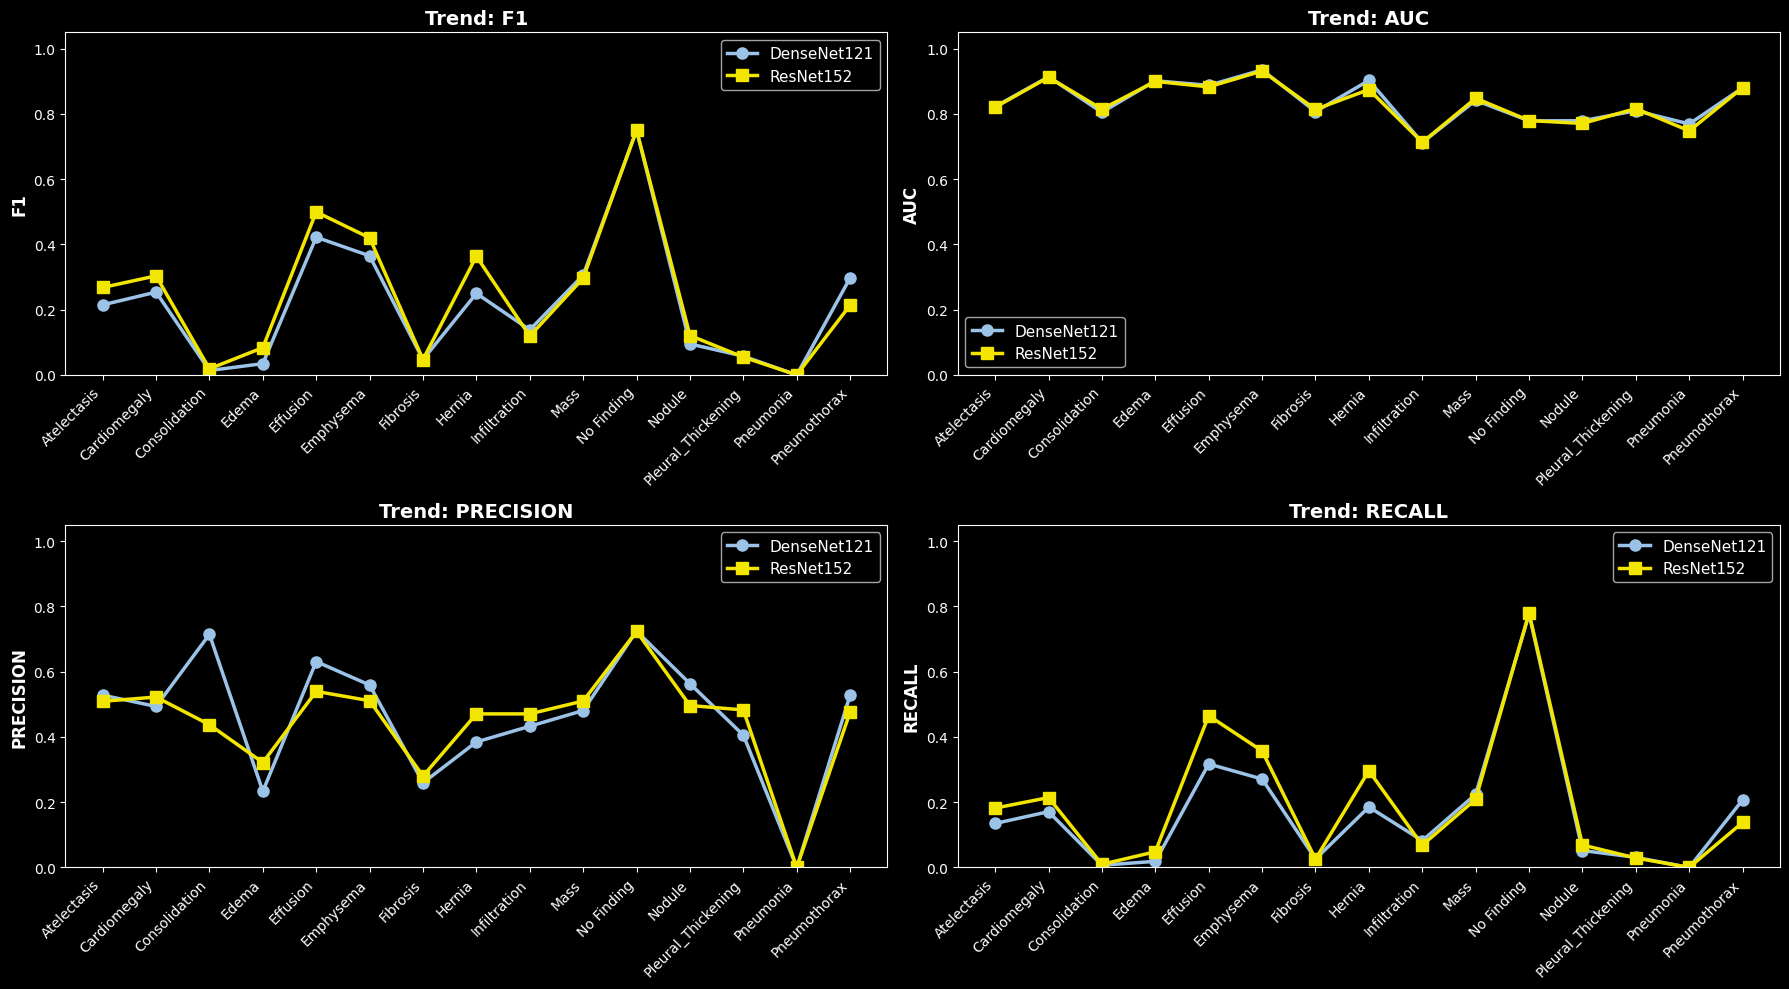

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
metrics_list = ["f1", "auc", "precision", "recall"]

for idx, metric in enumerate(metrics_list):
    ax = axs[idx//2, idx%2]
    ax.set_facecolor('black')
    ax.plot(range(len(CLASS_NAMES)), metrics_densenet[metric], marker='o', linewidth=2.5, markersize=8, label='DenseNet121', color='#9BC3E8')
    ax.plot(range(len(CLASS_NAMES)), metrics_resnet[metric], marker='s', linewidth=2.5, markersize=8, label='ResNet152', color='#F2E600')
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_ylabel(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_title(f"Trend: {metric.upper()}", fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('./plot1_line_trends.png', dpi=300, bbox_inches='tight')
plt.show()


[Plot] Multi-Metric Stacked Area - All 4 Metrics Stacked


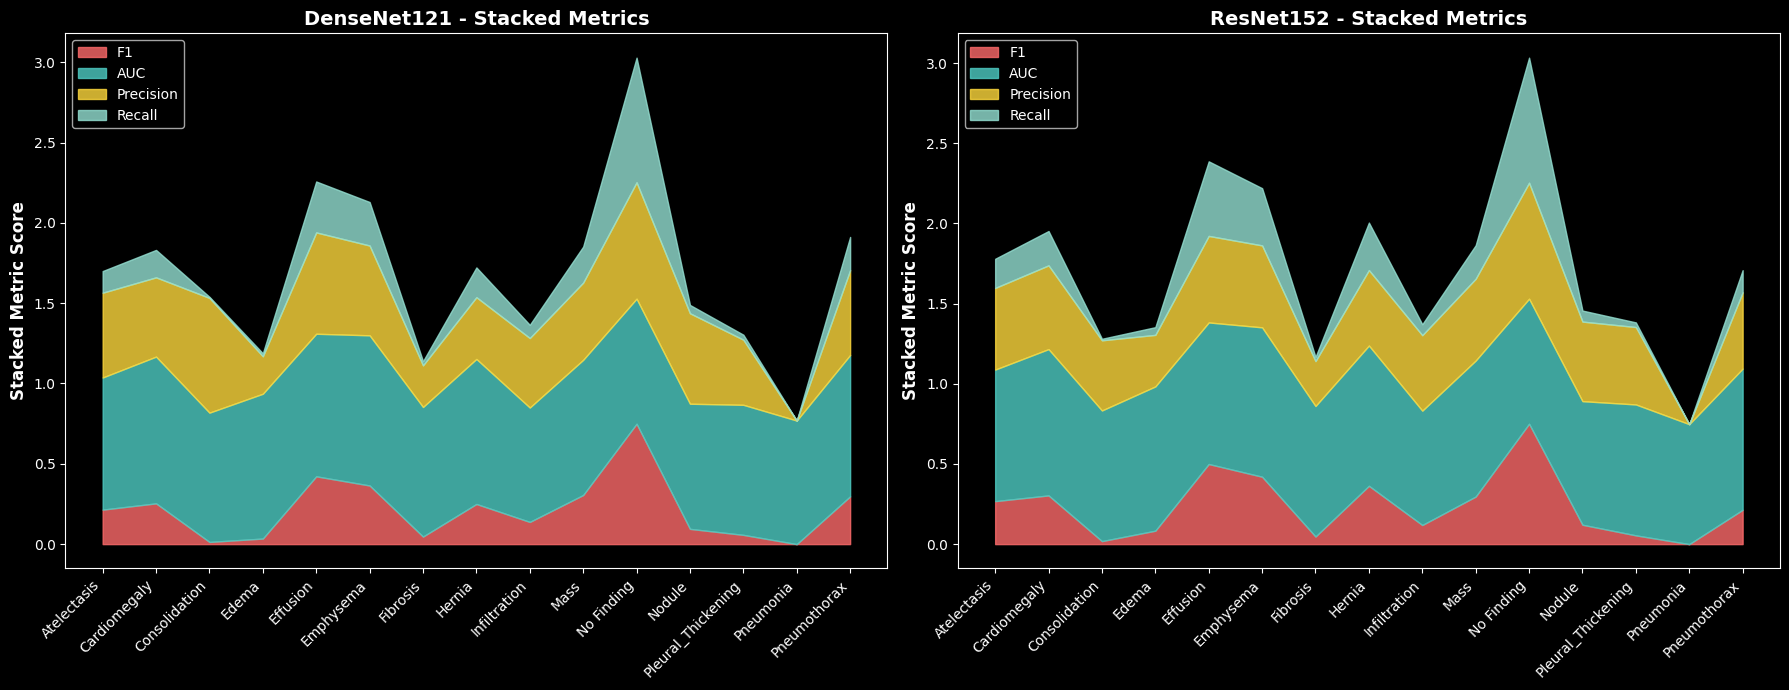

In [22]:
# ========== PLOT 3: MULTI-METRIC STACKED AREA (Like your example) ==========
print("\n[Plot] Multi-Metric Stacked Area - All 4 Metrics Stacked")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

x = np.arange(len(CLASS_NAMES))

# DenseNet121
ax1.fill_between(x, 0, metrics_densenet['f1'], alpha=0.8, color='#FF6B6B', label='F1')
ax1.fill_between(x, metrics_densenet['f1'], 
                 np.array(metrics_densenet['f1']) + np.array(metrics_densenet['auc']), 
                 alpha=0.8, color='#4ECDC4', label='AUC')
ax1.fill_between(x, np.array(metrics_densenet['f1']) + np.array(metrics_densenet['auc']),
                 np.array(metrics_densenet['f1']) + np.array(metrics_densenet['auc']) + np.array(metrics_densenet['precision']),
                 alpha=0.8, color='#FFD93D', label='Precision')
ax1.fill_between(x, np.array(metrics_densenet['f1']) + np.array(metrics_densenet['auc']) + np.array(metrics_densenet['precision']),
                 np.array(metrics_densenet['f1']) + np.array(metrics_densenet['auc']) + np.array(metrics_densenet['precision']) + np.array(metrics_densenet['recall']),
                 alpha=0.8, color='#95E1D3', label='Recall')

ax1.set_xticks(x)
ax1.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Stacked Metric Score', fontsize=12, fontweight='bold')
ax1.set_title('DenseNet121 - Stacked Metrics', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='upper left')

# ResNet152
ax2.fill_between(x, 0, metrics_resnet['f1'], alpha=0.8, color='#FF6B6B', label='F1')
ax2.fill_between(x, metrics_resnet['f1'], 
                 np.array(metrics_resnet['f1']) + np.array(metrics_resnet['auc']), 
                 alpha=0.8, color='#4ECDC4', label='AUC')
ax2.fill_between(x, np.array(metrics_resnet['f1']) + np.array(metrics_resnet['auc']),
                 np.array(metrics_resnet['f1']) + np.array(metrics_resnet['auc']) + np.array(metrics_resnet['precision']),
                 alpha=0.8, color='#FFD93D', label='Precision')
ax2.fill_between(x, np.array(metrics_resnet['f1']) + np.array(metrics_resnet['auc']) + np.array(metrics_resnet['precision']),
                 np.array(metrics_resnet['f1']) + np.array(metrics_resnet['auc']) + np.array(metrics_resnet['precision']) + np.array(metrics_resnet['recall']),
                 alpha=0.8, color='#95E1D3', label='Recall')

ax2.set_xticks(x)
ax2.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Stacked Metric Score', fontsize=12, fontweight='bold')
ax2.set_title('ResNet152 - Stacked Metrics', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('./plot_stacked_area_all_metrics_split.png', dpi=300, bbox_inches='tight')
plt.show()
